# Plot database
Make quick plots of the CTD database

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import cmocean
import xarray as xr
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
sys.path.append(os.path.abspath(os.path.join(notebook_dir, '../scripts')))
from functions import read_netCDF_xr

dmin=260

%matplotlib widget 
# Autosave every second:
# %autosave 1

In [2]:
database_file = "../data/ctd/Level3/Combined/L3_comb.nc"
data_CTD=read_netCDF_xr(database_file)
tnum=data_CTD["time"].values
ds = xr.decode_cf(xr.Dataset({"time": ("time", data_CTD.time.data,{"units":"seconds since 1970-01-01"})}))
data_CTD["time"]=ds["time"].data

In [3]:
print(data_CTD)

<xarray.Dataset>
Dimensions:       (time: 2581, depth_interp: 2400)
Coordinates:
  * time          (time) datetime64[ns] 2008-02-12T10:09:18 ... 2022-09-20T13...
  * depth_interp  (depth_interp) float64 0.0 0.2 0.4 0.6 ... 479.4 479.6 479.8
Data variables: (12/21)
    datetime      (time) float64 2.008e+13 2.008e+13 ... 2.022e+13 2.022e+13
    min_depth     (time) float64 1.8 1.8 1.8 1.8 1.8 1.8 ... 2.8 2.8 2.8 3.0 2.8
    max_depth     (time) float64 157.8 157.6 158.4 153.8 ... 325.8 321.0 324.0
    Press         (depth_interp, time) float64 nan nan nan nan ... nan nan nan
    Temp          (depth_interp, time) float64 nan nan nan nan ... nan nan nan
    Cond          (depth_interp, time) float64 nan nan nan nan ... nan nan nan
    ...            ...
    SALIN         (depth_interp, time) float64 nan nan nan nan ... nan nan nan
    Cond20        (depth_interp, time) float64 nan nan nan nan ... nan nan nan
    latitude      (time) float64 -1.733 -1.734 -1.734 ... -1.906 -1.816 -1.727
 

## Interpolated grid for deep profiles

In [4]:
ind_deepprof=np.where(data_CTD['max_depth'].values>=dmin)[0]

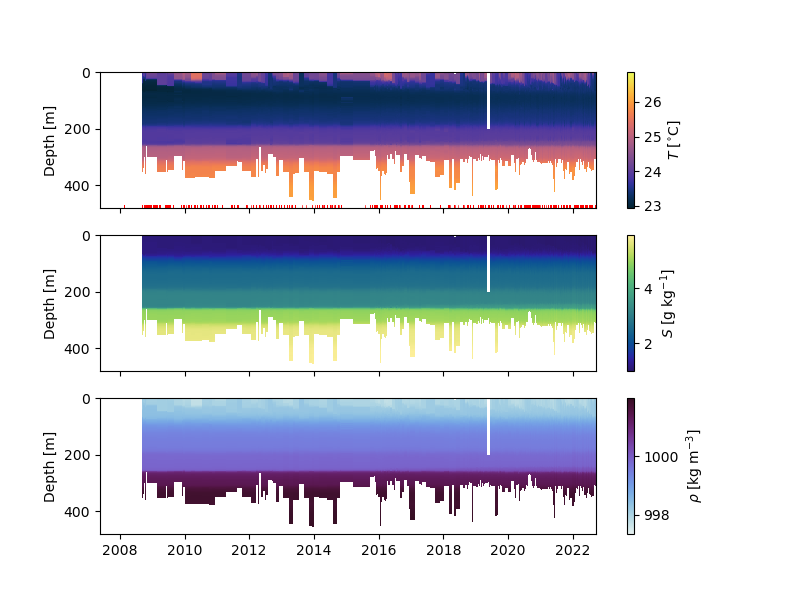

In [5]:
fig,ax = plt.subplots(3,1,figsize=(8,6),sharey=True,sharex=True)
x,y = np.meshgrid(data_CTD["time"][ind_deepprof],data_CTD["depth_interp"])
ptemp = ax[0].pcolormesh(x,y,data_CTD["Temp"][:,ind_deepprof],cmap=cmocean.cm.thermal)
cb=fig.colorbar(ptemp, ax=ax[0])
cb.set_label('$T$ [$^{\\circ}$C]')
ax[0].set_ylabel('Depth [m]')
ylimval=ax[0].get_ylim()
ax[0].set_ylim(ylimval)
for kprof in np.arange(len(data_CTD.time)):
    ax[0].plot(np.full(2,data_CTD.time[kprof]),np.array([ylimval[1]-10,ylimval[1]]),'-r',linewidth=0.5)

psal = ax[1].pcolormesh(x,y,data_CTD["SALIN"][:,ind_deepprof],cmap=cmocean.cm.haline)
cb=fig.colorbar(psal, ax=ax[1])
cb.set_label('$S$ [g kg$^{-1}$]')
ax[1].set_ylabel('Depth [m]')


prho = ax[2].pcolormesh(x,y,data_CTD["rho"][:,ind_deepprof],cmap=cmocean.cm.dense)
cb=fig.colorbar(prho, ax=ax[2])
cb.set_label('$\\rho$ [kg m$^{-3}$]')
ax[2].set_ylabel('Depth [m]')

ax[0].invert_yaxis()


## Specific profiles

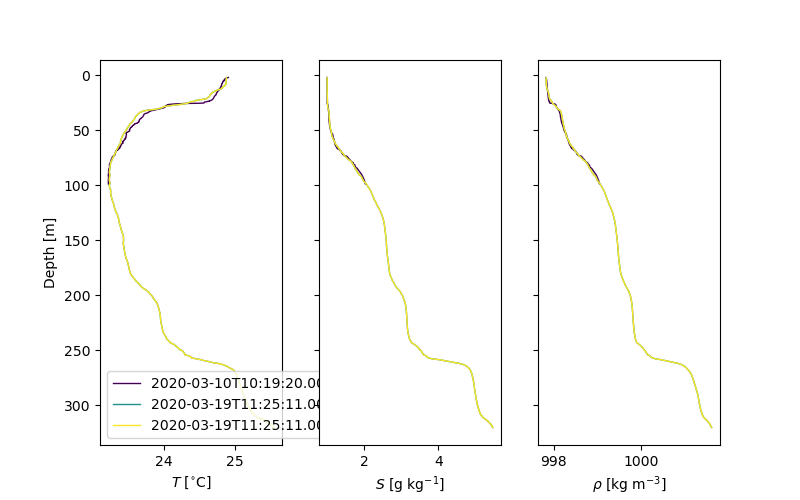

In [6]:
timeprof=[datetime(2020,3,10),datetime(2020,3,17,0,0,0),datetime(2020,3,17,12,0,0)]
timereal=[None]*len(timeprof)
indprof=np.full((len(timeprof),),np.nan)
col_prof=plt.get_cmap('viridis',len(timeprof))

fig,ax = plt.subplots(1,3,figsize=(8,5),sharey=True)
for k in range(len(indprof)):
    indval=np.argmin(np.abs(tnum-timeprof[k].replace(tzinfo=timezone.utc).timestamp()))
    indprof[k]=indval
    timereal[k]=data_CTD["time"].values[indval]
    ax[0].plot(data_CTD["Temp"].values[:,indval],data_CTD["depth_interp"].values,linewidth=1,color=col_prof(k))
    ax[1].plot(data_CTD["SALIN"].values[:,indval],data_CTD["depth_interp"].values,linewidth=1,color=col_prof(k))
    ax[2].plot(data_CTD["rho"].values[:,indval],data_CTD["depth_interp"].values,linewidth=1,color=col_prof(k))
ax[0].set_xlabel('$T$ [$^{\\circ}$C]')
ax[0].set_ylabel('Depth [m]')
ax[1].set_xlabel('$S$ [g kg$^{-1}$]')
ax[2].set_xlabel('$\\rho$ [kg m$^{-3}$]')
ax[0].invert_yaxis()
ax[0].legend(timereal)

In [7]:
data_CTD.close()